In [5]:
# ============================================================
# COVID-19 GLOBAL ANALYSIS
# Analyst: Oluwasijibomi Oderinde
# Date: April 2026
# Tools: Python, pandas, Matplotlib, Seaborn
# ============================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Load the dataset
df = pd.read_csv('/content/owid_covid_data.csv.csv')

# Display basic information
print("=== DATASET OVERVIEW ===")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes.value_counts())

=== DATASET OVERVIEW ===
Total rows: 350,108
Total columns: 67

First 5 rows:


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN



Column names:
['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hu

In [6]:
# ============================================================
# SELECT COUNTRIES FOR ANALYSIS
# ============================================================

# List of countries to analyze
selected_countries = [
    'United Kingdom',
    'United States',
    'India',
    'Brazil',
    'Nigeria',
    'South Africa'
]

# Check which locations are available
all_locations = df['location'].unique()
print(f"Total unique locations: {len(all_locations)}")

# Filter dataset for selected countries and world data
df_selected = df[df['location'].isin(selected_countries + ['World'])].copy()

# Convert date column to datetime
df_selected['date'] = pd.to_datetime(df_selected['date'])

# Display available date range
print(f"\nDate range: {df_selected['date'].min()} to {df_selected['date'].max()}")

# Show counts per location
print("\nRows per location:")
print(df_selected['location'].value_counts())

# Preview filtered data
display(df_selected[['location', 'date', 'total_cases', 'total_deaths', 'people_vaccinated_per_hundred']].head(10))

Total unique locations: 255

Date range: 2020-01-03 00:00:00 to 2023-10-24 00:00:00

Rows per location:
location
India             1391
World             1391
Brazil            1385
Nigeria           1385
South Africa      1385
United Kingdom    1385
United States     1385
Name: count, dtype: int64


,location,date,total_cases,total_deaths,people_vaccinated_per_hundred
41571,Brazil,2020-01-03,NaN,NaN,NaN
41572,Brazil,2020-01-04,NaN,NaN,NaN
41573,Brazil,2020-01-05,NaN,NaN,NaN
41574,Brazil,2020-01-06,NaN,NaN,NaN
41575,Brazil,2020-01-07,NaN,NaN,NaN
41576,Brazil,2020-01-08,NaN,NaN,NaN
41577,Brazil,2020-01-09,NaN,NaN,NaN
41578,Brazil,2020-01-10,NaN,NaN,NaN
41579,Brazil,2020-01-11,NaN,NaN,NaN
41580,Brazil,2020-01-12,NaN,NaN,NaN


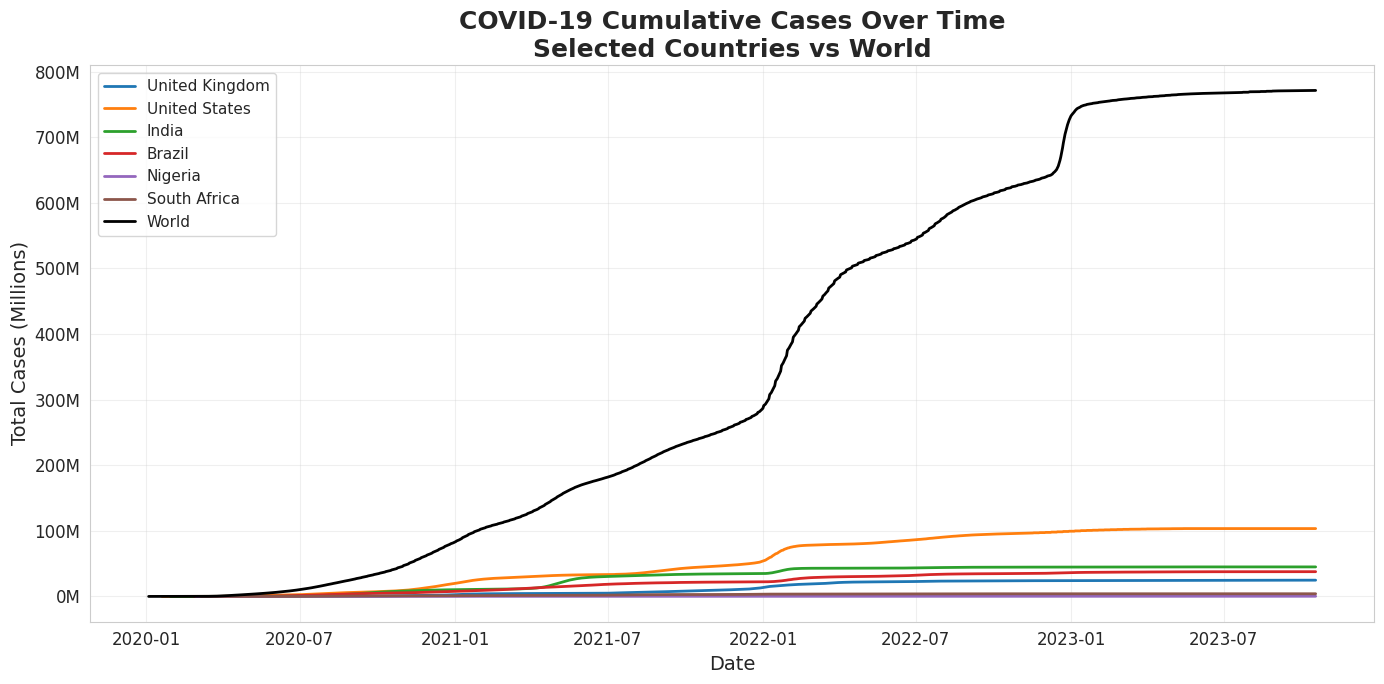

Plot saved as 'plot1_cumulative_cases.png'


In [8]:
# ============================================================
# VISUALIZATION 1: Cumulative Cases Over Time
# ============================================================

# Create the plot
fig, ax = plt.subplots(figsize=(14, 7))

# Define colors for each country
colors = {
    'United Kingdom': '#1f77b4',
    'United States': '#ff7f0e',
    'India': '#2ca02c',
    'Brazil': '#d62728',
    'Nigeria': '#9467bd',
    'South Africa': '#8c564b',
    'World': '#000000'
}

for country in selected_countries + ['World']:
    country_data = df_selected[df_selected['location'] == country].copy()
    country_data = country_data.sort_values('date')
    ax.plot(country_data['date'], country_data['total_cases'] / 1_000_000,
            label=country, color=colors[country], linewidth=2)

ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Total Cases (Millions)', fontsize=14)
ax.set_title('COVID-19 Cumulative Cases Over Time\nSelected Countries vs World', fontsize=18, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

# Format y-axis with 'M' for millions
from matplotlib.ticker import FuncFormatter
def millions_formatter(x, pos):
    return f'{x:.0f}M'
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig('plot1_cumulative_cases.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'plot1_cumulative_cases.png'")

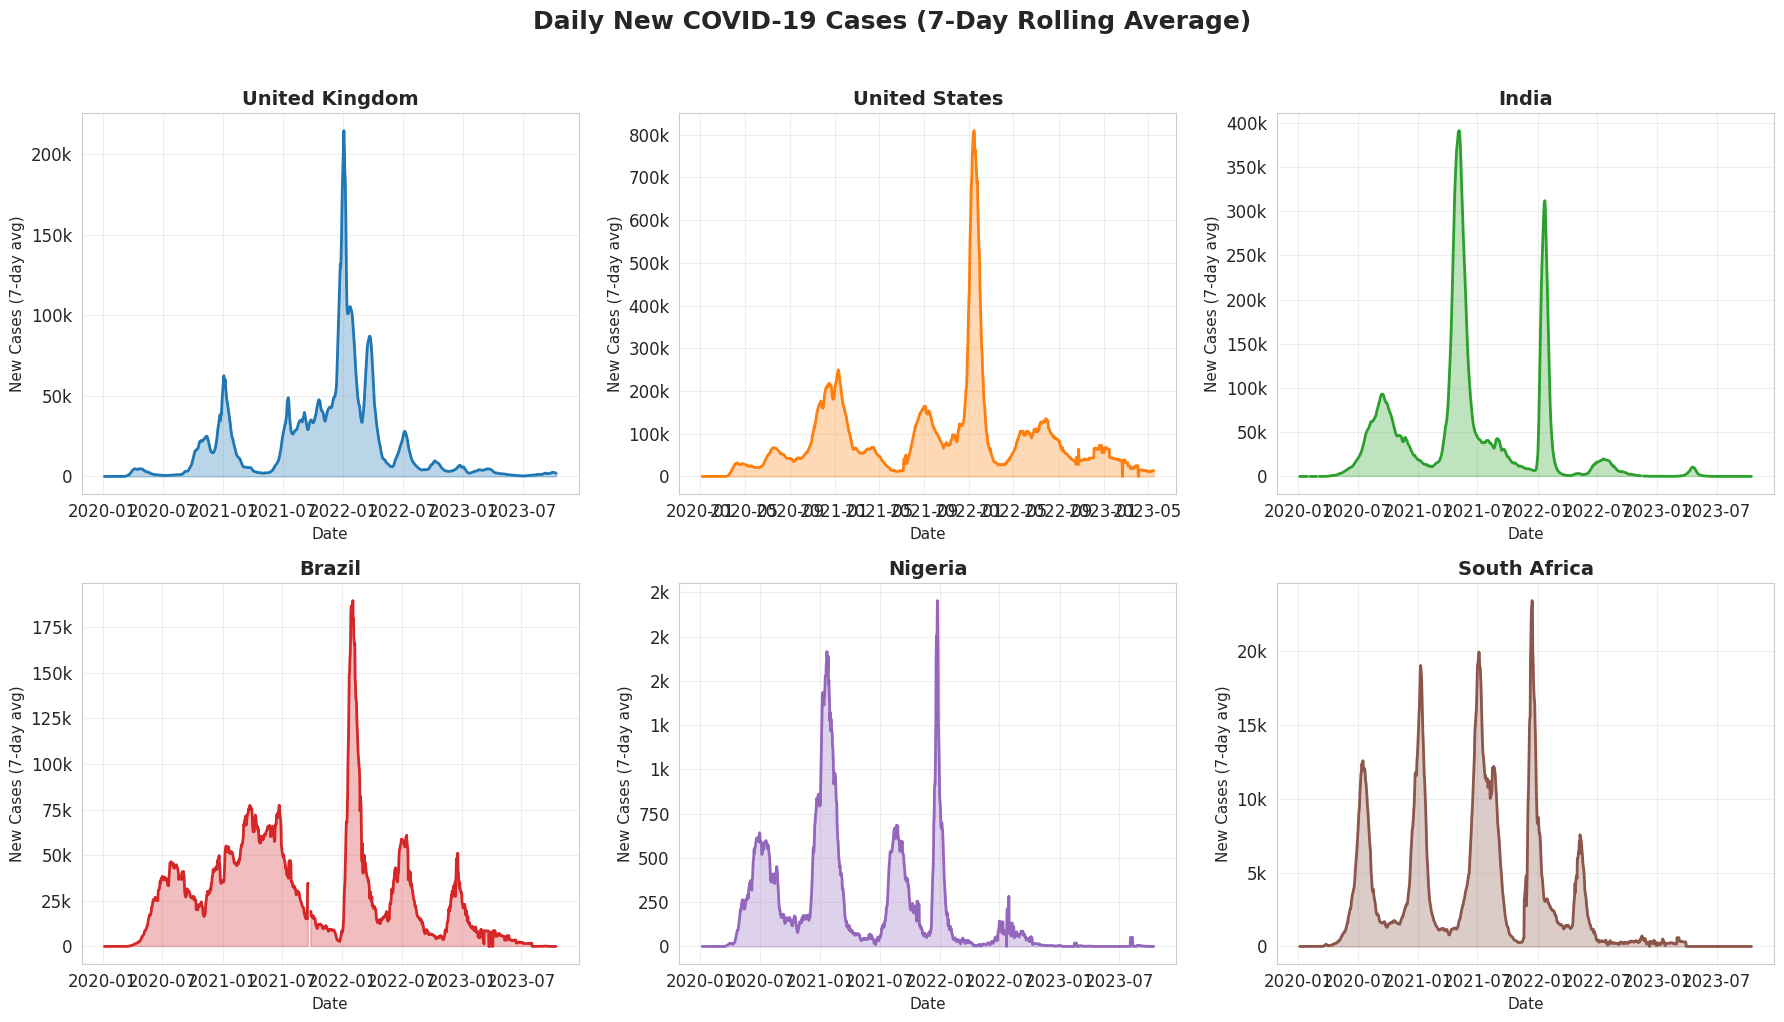

Plot saved as 'plot2_daily_new_cases.png'


In [9]:
# ============================================================
# VISUALIZATION 2: Daily New Cases (7-Day Rolling Average)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, country in enumerate(selected_countries):
    country_data = df_selected[df_selected['location'] == country].copy()
    country_data = country_data.sort_values('date')

    # Calculate daily new cases
    country_data['new_cases_smoothed'] = country_data['new_cases'].rolling(window=7, center=True).mean()

    ax = axes[idx]
    ax.plot(country_data['date'], country_data['new_cases_smoothed'],
            color=colors[country], linewidth=2)
    ax.fill_between(country_data['date'], 0, country_data['new_cases_smoothed'],
                     color=colors[country], alpha=0.3)

    ax.set_title(f'{country}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('New Cases (7-day avg)', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Format y-axis with 'k' for thousands
    def thousands_formatter(x, pos):
        return f'{x/1000:.0f}k' if x >= 1000 else f'{x:.0f}'
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

plt.suptitle('Daily New COVID-19 Cases (7-Day Rolling Average)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig.savefig('plot2_daily_new_cases.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'plot2_daily_new_cases.png'")

/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:1475: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(x))
/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))


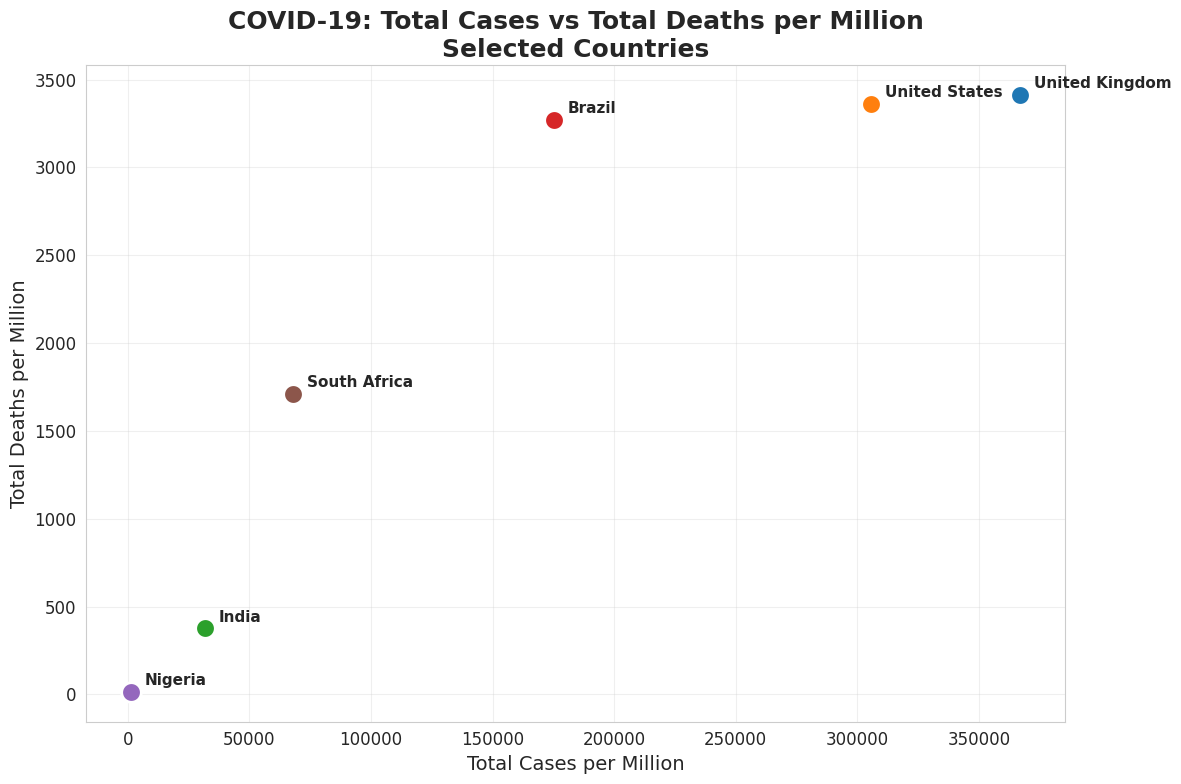

Plot saved as 'plot3_cases_vs_deaths.png'

=== MORTALITY RATE (Deaths per 100 cases) ===
Brazil: 1.87%
India: 1.18%
Nigeria: 1.18%
South Africa: 2.52%
United Kingdom: 0.93%
United States: 1.10%


In [10]:
# ============================================================
# VISUALIZATION 3: Total Cases vs Total Deaths by Country
# ============================================================

# Get latest data for each country
latest_data = df_selected[df_selected['location'].isin(selected_countries)].copy()
latest_data = latest_data.sort_values('date').groupby('location').last().reset_index()

fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot
for country in selected_countries:
    country_row = latest_data[latest_data['location'] == country]
    ax.scatter(country_row['total_cases_per_million'],
               country_row['total_deaths_per_million'],
               s=200, color=colors[country], label=country, edgecolors='white', linewidth=2)

    # Add country label near the point
    ax.annotate(country,
                (country_row['total_cases_per_million'], country_row['total_deaths_per_million']),
                xytext=(10, 5), textcoords='offset points', fontsize=11, fontweight='bold')

ax.set_xlabel('Total Cases per Million', fontsize=14)
ax.set_ylabel('Total Deaths per Million', fontsize=14)
ax.set_title('COVID-19: Total Cases vs Total Deaths per Million\nSelected Countries', fontsize=18, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig.savefig('plot3_cases_vs_deaths.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'plot3_cases_vs_deaths.png'")

# Display the mortality rate for each country
print("\n=== MORTALITY RATE (Deaths per 100 cases) ===")
latest_data['mortality_rate'] = (latest_data['total_deaths'] / latest_data['total_cases']) * 100
for _, row in latest_data.iterrows():
    print(f"{row['location']}: {row['mortality_rate']:.2f}%")

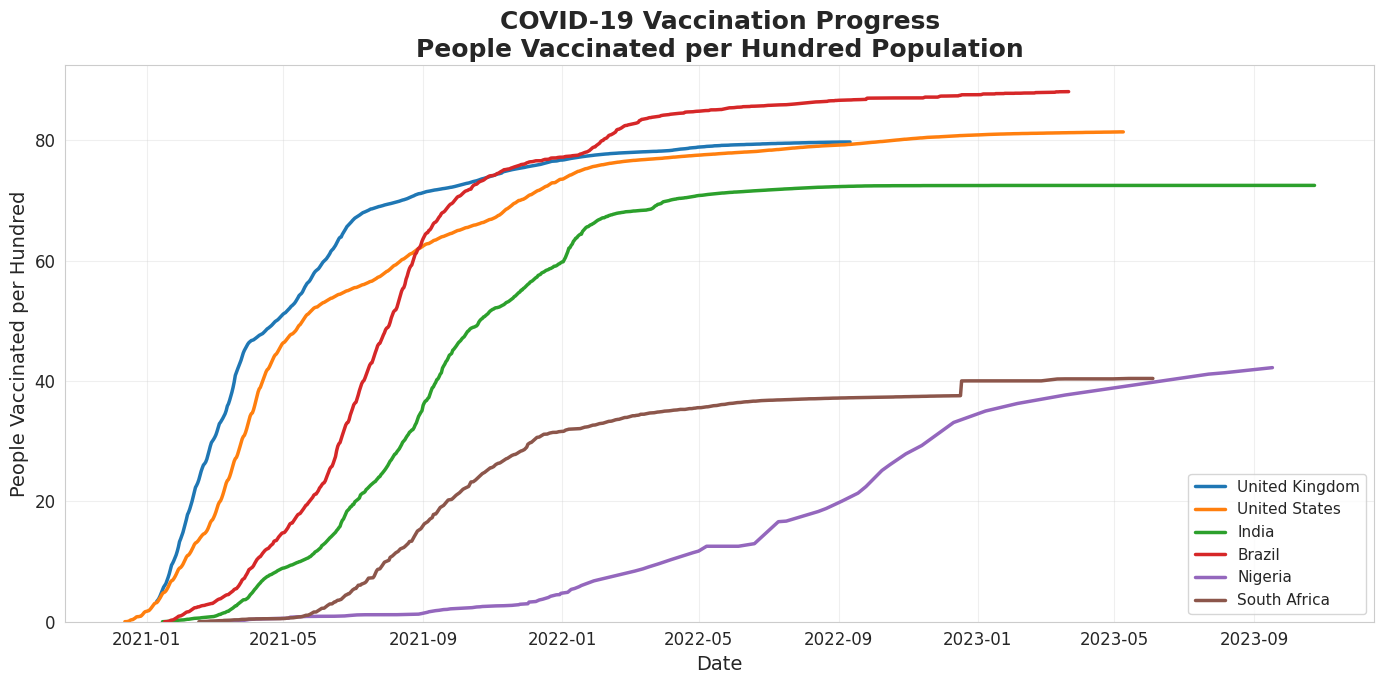

Plot saved as 'plot4_vaccination_progress.png'

=== LATEST VACCINATION RATES ===
United Kingdom: 79.7 per 100 people (as of 2022-09-11)
United States: 81.4 per 100 people (as of 2023-05-09)
India: 72.5 per 100 people (as of 2023-10-24)
Brazil: 88.1 per 100 people (as of 2023-03-22)
Nigeria: 42.2 per 100 people (as of 2023-09-17)
South Africa: 40.4 per 100 people (as of 2023-06-04)


In [11]:
# ============================================================
# VISUALIZATION 4: Vaccination Progress Over Time
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

for country in selected_countries:
    country_data = df_selected[df_selected['location'] == country].copy()
    country_data = country_data.sort_values('date')
    country_data = country_data.dropna(subset=['people_vaccinated_per_hundred'])

    if len(country_data) > 0:
        ax.plot(country_data['date'], country_data['people_vaccinated_per_hundred'],
                label=country, color=colors[country], linewidth=2.5)

ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('People Vaccinated per Hundred', fontsize=14)
ax.set_title('COVID-19 Vaccination Progress\nPeople Vaccinated per Hundred Population', fontsize=18, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

fig.savefig('plot4_vaccination_progress.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'plot4_vaccination_progress.png'")

# Display latest vaccination rates
print("\n=== LATEST VACCINATION RATES ===")
for country in selected_countries:
    country_data = df_selected[df_selected['location'] == country].copy()
    country_data = country_data.dropna(subset=['people_vaccinated_per_hundred'])
    if len(country_data) > 0:
        latest = country_data.sort_values('date').iloc[-1]
        print(f"{country}: {latest['people_vaccinated_per_hundred']:.1f} per 100 people (as of {latest['date'].strftime('%Y-%m-%d')})")

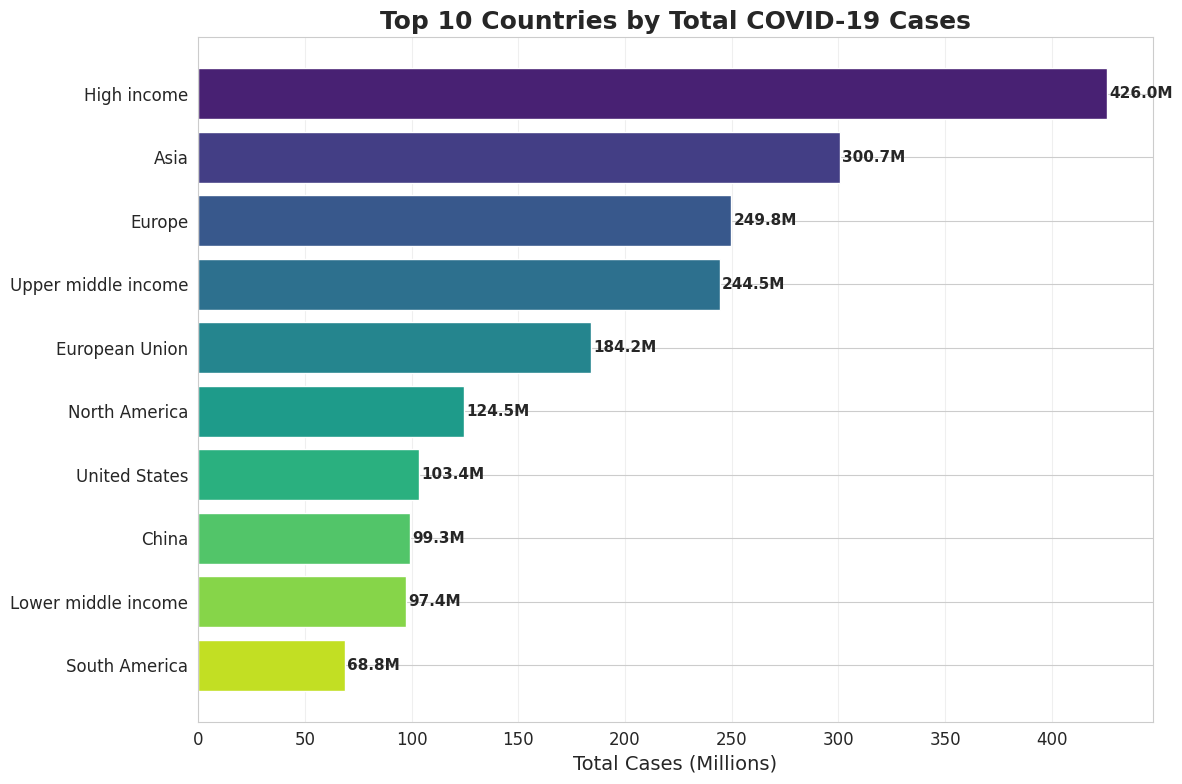

Plot saved as 'plot5_top_10_countries.png'

=== TOP 10 COUNTRIES BY TOTAL CASES ===


,location,total_cases,total_deaths
96,High income,425988398.0,2914272.0
12,Asia,300681974.0,1633880.0
70,Europe,249783754.0,2079783.0
241,Upper middle income,244463792.0,2666760.0
71,European Union,184210531.0,1245398.0
162,North America,124492151.0,1613118.0
239,United States,103436829.0,1136920.0
44,China,99315684.0,121742.0
128,Lower middle income,97423102.0,1339160.0
211,South America,68830317.0,1356419.0


In [12]:
# ============================================================
# VISUALIZATION 5: Top 10 Countries by Total Cases
# ============================================================

# Get latest data for all countries
all_latest = df[df['location'] != 'World'].copy()
all_latest = all_latest.sort_values('date').groupby('location').last().reset_index()
all_latest = all_latest.dropna(subset=['total_cases'])

# Get top 10 by total cases
top_10_cases = all_latest.nlargest(10, 'total_cases')[['location', 'total_cases', 'total_deaths']]
top_10_cases['cases_millions'] = top_10_cases['total_cases'] / 1_000_000

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(top_10_cases['location'][::-1], top_10_cases['cases_millions'][::-1],
               color=sns.color_palette("viridis", 10)[::-1])

ax.set_xlabel('Total Cases (Millions)', fontsize=14)
ax.set_ylabel('')
ax.set_title('Top 10 Countries by Total COVID-19 Cases', fontsize=18, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for bar, value in zip(bars, top_10_cases['cases_millions'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{value:.1f}M', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

fig.savefig('plot5_top_10_countries.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'plot5_top_10_countries.png'")

# Display the table
print("\n=== TOP 10 COUNTRIES BY TOTAL CASES ===")
display(top_10_cases[['location', 'total_cases', 'total_deaths']])

In [13]:
# ============================================================
# DOWNLOAD ALL VISUALIZATIONS
# ============================================================

from google.colab import files
import glob

# List all PNG files created
png_files = glob.glob('*.png')
print(f"Found {len(png_files)} PNG files:")

for file in png_files:
    print(f"  - {file}")
    files.download(file)

print("\nAll files downloaded. Check your Downloads folder.")

Found 5 PNG files:
  - plot2_daily_new_cases.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  - plot5_top_10_countries.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  - plot3_cases_vs_deaths.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded. Check your Downloads folder.


In [14]:
# ============================================================
# SAVE CLEANED DATA
# ============================================================

# Save the selected countries data to CSV
df_selected.to_csv('covid19_selected_countries_clean.csv', index=False)

# Download the cleaned data
files.download('covid19_selected_countries_clean.csv')

print("Cleaned data saved and downloaded.")
print(f"Rows: {len(df_selected):,}")
print(f"Columns: {len(df_selected.columns)}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cleaned data saved and downloaded.
Rows: 9,707
Columns: 67
